# SOCIETY: Backbone × Clusterer Selection with Feature Interpretation

이 노트북은 **DINOv2 vs SigLIP2**, **K-means / DBSCAN / HDBSCAN**, **UMAP vs t-SNE**를 단계적으로 비교하고,
최종적으로 **어떤 조합을 선택할지 근거(품질/안정성/해석성)**를 시각화 중심으로 제시합니다.

**대상 데이터:** `Data/SOCIETY/SOCIETY_final_kr_clean_add_color_text_person_ratio_title.csv`

## 실행 원칙
- 클러스터링은 **원본 임베딩 공간**에서 수행
- UMAP / t-SNE는 **시각화용**
- 최종 선택은 단일 지표가 아니라 **품질 + 안정성 + 피처 해석** 종합


## 1) 설정 및 경로

In [1]:
import sys
print(sys.executable)
import transformers
print(transformers.__version__)

/home/urp_jwl2/miniconda3/envs/ytvenv/bin/python


/home/urp_jwl2/miniconda3/envs/ytvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


5.5.0


In [2]:
# Runtime override: use GPU embedding extraction when CUDA is available
DEVICE_EMB = 'cuda'
print('DEVICE_EMB override ->', DEVICE_EMB)

DEVICE_EMB override -> cuda


In [ ]:
from __future__ import annotations

import csv
import json
import os
import re
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image

from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    balanced_accuracy_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import kruskal, chi2_contingency

try:
    import hdbscan  # type: ignore
    HAS_HDBSCAN = True
except Exception:
    HAS_HDBSCAN = False
    print('[warn] hdbscan 미설치: `%pip install hdbscan`')

try:
    import umap  # type: ignore
except Exception as e:
    raise RuntimeError('umap-learn 필요: %pip install umap-learn') from e

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '4')

def _try_set_cjk_font() -> None:
    plt.rcParams['axes.unicode_minus'] = False
    for f in font_manager.fontManager.ttflist:
        name = f.name or ''
        if any(k in name for k in ('Nanum', 'Noto Sans CJK', 'Malgun', 'AppleGothic', 'Source Han')):
            plt.rcParams['font.family'] = name
            return

_try_set_cjk_font()

# ── 프로젝트 루트 자동 탐색 ──────────────────────────────────────────────
# SOCIETY CSV가 있는 경로를 기준으로 ROOT를 찾습니다.
_SOCIETY_CSV_REL = Path('Data') / 'SOCIETY' / 'SOCIETY_final_kr_clean_add_color_text_person_ratio_title.csv'

def _find_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / _SOCIETY_CSV_REL).is_file():
            return base
    # Cursor가 파일 경로로 실행하는 경우 대비: 절대경로 fallback
    for nb_path in Path(__file__).resolve().parents if '__file__' in dir() else []:
        if (nb_path / _SOCIETY_CSV_REL).is_file():
            return nb_path
    raise FileNotFoundError(
        f'SOCIETY CSV를 찾지 못했습니다.\n'
        f'  탐색한 경로: {cwd} (및 상위 폴더들)\n'
        f'  찾는 파일: {{ROOT}}/{_SOCIETY_CSV_REL}'
    )

ROOT = _find_root()
CATEGORY = 'SOCIETY'
DATASET_CSV = ROOT / _SOCIETY_CSV_REL

OUT_BASE = ROOT / 'artifacts' / CATEGORY / 'analysis'
OUT_TABLES = OUT_BASE / 'tables'
OUT_PLOTS  = OUT_BASE / 'plots'
OUT_EMB    = OUT_BASE / 'embeddings'
for d in (OUT_TABLES, OUT_PLOTS, OUT_EMB):
    d.mkdir(parents=True, exist_ok=True)

BACKBONES = {
    'dinov2-base':  'facebook/dinov2-base',
    'siglip2-base': 'google/siglip2-base-patch16-224',
}

DEVICE_EMB         = 'cuda'   # 'cuda' | 'cpu' | 'auto'
BATCH_SIZE_EMB     = 32
REBUILD_EMBEDDINGS = False    # True 로 바꾸면 기존 .npy 무시하고 재추출

RANDOM_STATE    = 42
SEEDS_STABILITY = [11, 22, 33, 44, 55]
SUBSAMPLE_FRACS = [0.7, 0.8, 0.9]

K_RANGE                    = list(range(2, 11))
DBSCAN_EPS_LIST            = [0.22, 0.25, 0.28, 0.30, 0.33, 0.36, 0.40]
DBSCAN_MIN_SAMPLES_LIST    = [6, 8, 10, 12, 15]
HDBSCAN_MIN_CLUSTER_SIZE_LIST = [12, 16, 20, 30, 40]
HDBSCAN_MIN_SAMPLES_LIST   = [None, 5, 8, 10]

UMAP_NEIGHBORS  = 20
UMAP_MIN_DIST   = 0.1
TSNE_PERPLEXITY = 30

print('ROOT:    ', ROOT)
print('DATASET: ', DATASET_CSV)
print('OUT_BASE:', OUT_BASE)


## 2) Backbone별 채널 임베딩 생성/로드 (DINOv2, SigLIP2)

In [ ]:
def _write_csv_rows(path: Path, fieldnames: Sequence[str], rows: Iterable[Dict]) -> None:
    with path.open('w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for row in rows:
            w.writerow(row)


def _read_csv_rows(path: Path, encoding: str = 'utf-8') -> List[Dict[str, str]]:
    with path.open('r', encoding=encoding, newline='') as f:
        return list(csv.DictReader(f))


AUTO_REPAIR_MISSING_THUMBNAILS = True
THUMBNAIL_REPAIR_TIMEOUT_SEC   = 20
THUMBNAIL_REPAIR_RETRIES       = 2


def _thumbnail_path_candidates(raw_path: str, root: Path) -> list[Path]:
    raw = (raw_path or '').strip().replace('\\', os.sep)
    if not raw:
        return []
    p = Path(raw)
    candidates: list[Path] = []
    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.append(root / p)
        parts = p.parts
        if parts and parts[0].lower() == 'data':
            rel = Path(*parts[1:]) if len(parts) > 1 else Path('.')
            candidates.append(root / 'Data' / rel)
        candidates.append(root / 'Data' / p)
    out: list[Path] = []
    seen: set[str] = set()
    for c in candidates:
        rc = str(c)
        if rc not in seen:
            seen.add(rc)
            out.append(c)
    return out


def resolve_thumbnail_path(row: dict, root: Path) -> Path | None:
    # SOCIETY CSV의 썸네일 경로 컬럼은 'thumbnail_path_x'
    raw = (row.get('thumbnail_path_x') or '').strip()
    for c in _thumbnail_path_candidates(raw, root):
        if c.is_file():
            return c
    return None


def _download_thumbnail_for_row(row: dict, root: Path) -> Path | None:
    import requests
    if not AUTO_REPAIR_MISSING_THUMBNAILS:
        return None
    raw = (row.get('thumbnail_path_x') or '').strip()
    url = (row.get('thumbnail_url_x') or '').strip()
    if not raw or not url:
        return None
    candidates = _thumbnail_path_candidates(raw, root)
    if not candidates:
        return None
    target = candidates[0]
    try:
        target.parent.mkdir(parents=True, exist_ok=True)
        last_err = None
        for _ in range(THUMBNAIL_REPAIR_RETRIES):
            try:
                resp = requests.get(url, timeout=THUMBNAIL_REPAIR_TIMEOUT_SEC)
                resp.raise_for_status()
                target.write_bytes(resp.content)
                if target.is_file() and target.stat().st_size > 0:
                    return target
            except Exception as e:
                last_err = e
        if last_err is not None:
            raise last_err
    except Exception:
        return None
    return None


@dataclass
class LoadedModel:
    model_id: str
    alias: str
    processor: object
    model: object
    device: str


def _resolve_device(requested: str) -> str:
    if requested != 'auto':
        return requested
    try:
        import torch
        if torch.cuda.is_available():
            return 'cuda'
    except Exception:
        pass
    return 'cpu'


def _load_transformers_model(alias: str, model_id: str, device: str) -> LoadedModel:
    from transformers import AutoImageProcessor, AutoModel, AutoProcessor
    model = AutoModel.from_pretrained(model_id)
    try:
        processor = AutoProcessor.from_pretrained(model_id)
    except Exception:
        processor = AutoImageProcessor.from_pretrained(model_id)
    model = model.to(device).eval()
    return LoadedModel(model_id=model_id, alias=alias, processor=processor, model=model, device=device)


def _extract_batch_embeddings(loaded: LoadedModel, images: list) -> list[np.ndarray]:
    import torch
    inputs = loaded.processor(images=images, return_tensors='pt')
    inputs = {k: v.to(loaded.device) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
    with torch.no_grad():
        outputs = loaded.model(**inputs)
    if hasattr(outputs, 'last_hidden_state') and outputs.last_hidden_state is not None:
        emb = outputs.last_hidden_state[:, 0, :]
    elif hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
        emb = outputs.pooler_output
    else:
        first = outputs[0] if isinstance(outputs, (tuple, list)) else None
        if first is None:
            raise RuntimeError(f'unexpected model output type: {type(outputs)}')
        emb = first[:, 0, :] if first.ndim == 3 else first
    arr = emb.detach().float().cpu().numpy()
    return [arr[i] for i in range(arr.shape[0])]


def _is_cuda_related_error(exc: Exception) -> bool:
    msg = str(exc).lower()
    return any(k in msg for k in ('cuda', 'cudnn', 'nvidia driver', 'no kernel image'))


def build_or_load_channel_embeddings(alias: str, model_id: str) -> Tuple[np.ndarray, pd.DataFrame]:
    model_dir = OUT_EMB / alias
    model_dir.mkdir(parents=True, exist_ok=True)
    emb_path  = model_dir / 'channel_embeddings.npy'
    meta_path = model_dir / 'channel_metadata.csv'
    need = REBUILD_EMBEDDINGS or (not emb_path.is_file()) or (not meta_path.is_file())

    if need:
        # SOCIETY CSV 컬럼명: channel_id_x, channel_name_x, thumbnail_path_x
        rows = _read_csv_rows(DATASET_CSV, encoding='utf-8-sig')
        rows = [r for r in rows if (r.get('channel_id_x') or '').strip()]

        dev = _resolve_device(DEVICE_EMB)
        try:
            loaded = _load_transformers_model(alias, model_id, dev)
        except Exception as e:
            if dev == 'cuda' and _is_cuda_related_error(e):
                print(f'[warn] {alias}: CUDA init failed -> fallback to CPU ({e})')
                loaded = _load_transformers_model(alias, model_id, 'cpu')
            else:
                raise

        runtime_batch  = BATCH_SIZE_EMB if loaded.device == 'cuda' else min(BATCH_SIZE_EMB, 8)
        progress_every = 1 if loaded.device == 'cpu' else 20
        print(
            f'[extract] {alias} ({loaded.model_id}) on {loaded.device} '
            f'/ rows={len(rows)} / batch={runtime_batch} / progress_every={progress_every}'
        )

        valid_meta: list[Dict[str, str]] = []
        emb_list: list[np.ndarray] = []
        missing_path_count = 0
        missing_path_samples: list[str] = []
        open_fail_count = 0

        for i in range(0, len(rows), runtime_batch):
            chunk = rows[i : i + runtime_batch]
            images, metas = [], []
            repaired = 0
            for r in chunk:
                p = resolve_thumbnail_path(r, ROOT)
                if p is None:
                    p = _download_thumbnail_for_row(r, ROOT)
                    if p is not None:
                        repaired += 1
                if p is None:
                    missing_path_count += 1
                    raw = str((r.get('thumbnail_path_x') or '')).strip()
                    if raw and len(missing_path_samples) < 8:
                        missing_path_samples.append(raw)
                    continue
                try:
                    with Image.open(p) as img:
                        images.append(img.convert('RGB'))
                    metas.append({
                        'channel_id':   str(r.get('channel_id_x',   '')).strip(),
                        'channel_name': str(r.get('channel_name_x', '')).strip(),
                    })
                except Exception:
                    open_fail_count += 1
                    continue
            if repaired:
                print(f'  repaired thumbnails in chunk: +{repaired}')
            if not images:
                continue
            try:
                batch_emb = _extract_batch_embeddings(loaded, images)
            except Exception as e:
                if loaded.device == 'cuda' and _is_cuda_related_error(e):
                    print(f'[warn] CUDA batch failed at row={i} -> CPU')
                    loaded = _load_transformers_model(alias, model_id, 'cpu')
                    batch_emb = _extract_batch_embeddings(loaded, images)
                else:
                    raise
            emb_list.extend(batch_emb)
            valid_meta.extend(metas)
            if (i // runtime_batch) % progress_every == 0:
                print(f'  progress: {i}/{len(rows)} (device={loaded.device})')

        if not emb_list:
            raise RuntimeError(
                f'no embeddings extracted for {alias}.\n'
                f'missing thumbnail_path_x count={missing_path_count}, open_fail={open_fail_count}\n'
                f'sample missing paths={missing_path_samples[:5]}'
            )

        X_vid = np.asarray(emb_list, dtype=np.float32)
        _write_csv_rows(model_dir / 'video_metadata.csv', ['channel_id', 'channel_name'], valid_meta)
        np.save(model_dir / 'video_embeddings.npy', X_vid)

        groups: dict[str, list[int]] = defaultdict(list)
        ch_name: dict[str, str] = {}
        for i, r in enumerate(valid_meta):
            cid = str(r['channel_id']).strip()
            if not cid:
                continue
            groups[cid].append(i)
            ch_name[cid] = str(r.get('channel_name', '')).strip()

        cids = sorted(groups.keys())
        X_ch = np.stack([X_vid[groups[c]].mean(axis=0) for c in cids], axis=0)
        norms = np.linalg.norm(X_ch, axis=1, keepdims=True)
        norms = np.where(norms < 1e-12, 1.0, norms)
        X_ch = (X_ch / norms).astype(np.float32)

        np.save(emb_path, X_ch)
        rows_out = [
            {'channel_id': c, 'channel_name': ch_name.get(c, ''), 'n_videos': str(len(groups[c]))}
            for c in cids
        ]
        _write_csv_rows(meta_path, ['channel_id', 'channel_name', 'n_videos'], rows_out)
        print(f'  saved: {emb_path} shape={X_ch.shape}')

    X = np.load(emb_path).astype(np.float64)
    meta = pd.read_csv(meta_path, encoding='utf-8')
    meta['channel_id'] = meta['channel_id'].astype(str).str.strip()
    assert X.shape[0] == len(meta), (X.shape, len(meta))
    return X, meta


X_by_backbone:    Dict[str, np.ndarray]    = {}
meta_by_backbone: Dict[str, pd.DataFrame] = {}

for alias, model_id in BACKBONES.items():
    try:
        X_, meta_ = build_or_load_channel_embeddings(alias, model_id)
        X_by_backbone[alias]    = X_
        meta_by_backbone[alias] = meta_
    except Exception as e:
        print(f'[warn] backbone skip: {alias} ({e})')

if not X_by_backbone:
    raise RuntimeError('No backbone embeddings are available.')

print('available backbones:', list(X_by_backbone.keys()))


## 3) 공통 채널 조인 + 피처 행렬 준비

In [ ]:
# SOCIETY CSV에는 피처가 이미 내장되어 있으므로 채널별로 평균 집계합니다.
# 집계 대상 피처 컬럼 (수치형 전체)
FEATURE_COLS = [
    'saturation_mean', 'saturation_std', 'laba_mean', 'labb_mean',
    'color_entropy', 'saturated_ratio',
    'red_ratio', 'orange_ratio', 'yellow_ratio', 'green_ratio',
    'cyan_ratio', 'blue_ratio', 'purple_ratio', 'pink_ratio',
    'text_ratio', 'person_ratio',
    'female_pct', 'male_pct',
    'age_~17', 'age_18~24', 'age_25~34', 'age_35~44',
    'age_45~54', 'age_55~64', 'age_65~',
    'clean_title_x_length',
]

# 원본 CSV 로드 후 채널별 평균
_raw = pd.read_csv(DATASET_CSV, encoding='utf-8-sig', low_memory=False)
_raw = _raw.rename(columns={'channel_id_x': 'channel_id', 'channel_name_x': 'channel_name'})
_raw['channel_id'] = _raw['channel_id'].astype(str).str.strip()

# 피처 컬럼 중 실제 존재하는 것만 사용
feature_cols = [c for c in FEATURE_COLS if c in _raw.columns]
missing_feat = [c for c in FEATURE_COLS if c not in _raw.columns]
if missing_feat:
    print(f'[warn] 피처 컬럼 없음 (건너뜀): {missing_feat}')

# 채널별 피처 평균 집계
feat_df = (
    _raw.groupby('channel_id', as_index=False)
    [['channel_name'] + feature_cols]
    .agg({'channel_name': 'first', **{c: 'mean' for c in feature_cols}})
)
feat_df['channel_id'] = feat_df['channel_id'].astype(str).str.strip()
name_col = 'channel_name'
feat_ids = set(feat_df['channel_id'].tolist())
print(f'채널 수 (피처 집계): {len(feat_df)} | 피처 수: {len(feature_cols)}')

common_ids = set(feat_ids)
for alias, meta in meta_by_backbone.items():
    meta_ids = set(meta['channel_id'].astype(str).tolist())
    before = len(common_ids)
    common_ids &= meta_ids
    print(f'  intersect with {alias}: {before} -> {len(common_ids)} (meta={len(meta_ids)})')

common_ids = sorted(common_ids)
print(f'공통 채널 수 (피처 & 모든 백본): {len(common_ids)}')
if len(common_ids) < 10:
    raise RuntimeError(
        f'공통 채널이 너무 적습니다 ({len(common_ids)}개). '
        f'channel_id 정합성을 확인하세요.'
    )

# 진단
for alias, meta in meta_by_backbone.items():
    meta_ids = set(meta['channel_id'].astype(str).tolist())
    print(f'  diag {alias}: feature_only={len(feat_ids - meta_ids)}, backbone_only={len(meta_ids - feat_ids)}')

# backbone_data 준비
backbone_data: Dict[str, Dict[str, Any]] = {}
feat_df_idx = feat_df.set_index('channel_id')

for alias in X_by_backbone:
    X_all = X_by_backbone[alias]
    meta  = meta_by_backbone[alias].copy()
    meta['channel_id'] = meta['channel_id'].astype(str).str.strip()
    id_to_idx = {cid: i for i, cid in enumerate(meta['channel_id'].tolist())}

    ordered_ids = [cid for cid in common_ids if (cid in feat_df_idx.index and cid in id_to_idx)]
    feat_sub = feat_df_idx.loc[ordered_ids, feature_cols + [name_col]].reset_index()

    idx = [id_to_idx[cid] for cid in ordered_ids]
    X = X_all[idx].astype(np.float64)
    F = feat_sub[feature_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float64)

    merged = feat_sub.copy()
    merged['channel_name_meta'] = [meta.loc[id_to_idx[cid], 'channel_name'] for cid in ordered_ids]

    backbone_data[alias] = {
        'X': X,
        'F': F,
        'merged': merged,
        'feature_cols': feature_cols,
    }
    print(f'  prepared {alias}: X={X.shape}, F={F.shape}, merged={merged.shape}')

print('backbones prepared:', list(backbone_data.keys()))
print('feature count:', len(feature_cols))


## 4) 클러스터링 sweep (K-means / DBSCAN / HDBSCAN)

### Plot 1
- Backbone × Method best-score heatmap

### Plot 2
- 파라미터 민감도(DBSCAN/HDBSCAN)

,run_id,backbone,method,n_clusters,noise_ratio,sil_pref,score
57,dinov2-base|hdbscan|mcs=30|ms=5,dinov2-base,hdbscan,2,0.460026,0.227056,0.130869
38,dinov2-base|dbscan|eps=0.36|ms=15,dinov2-base,dbscan,2,0.399738,0.210259,0.043991
1,dinov2-base|kmeans|k=3,dinov2-base,kmeans,3,0.000000,0.103199,-0.713701


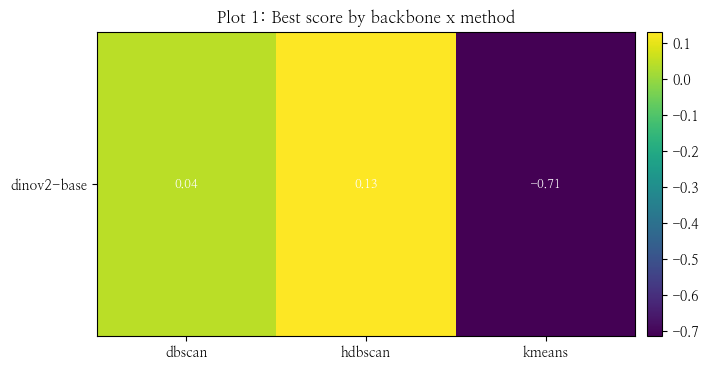

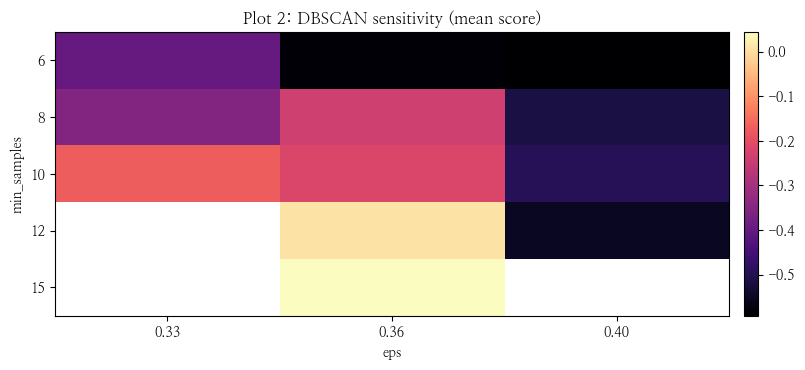

In [6]:
def evaluate_labels(X: np.ndarray, labels: np.ndarray) -> Dict[str, Any]:
    labels = np.asarray(labels, dtype=np.int64)
    mask = labels != -1
    n = int(labels.shape[0])
    n_noise = int((labels == -1).sum())
    n_clusters = int(len(set(labels.tolist()) - {-1}))

    out: Dict[str, Any] = {
        'n_samples': n,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': float(n_noise / max(1, n)),
        'silhouette_all': np.nan,
        'silhouette_wo_noise': np.nan,
        'dbi_wo_noise': np.nan,
        'ch_wo_noise': np.nan,
    }

    if n_clusters >= 2 and np.unique(labels).shape[0] >= 2:
        try:
            out['silhouette_all'] = float(silhouette_score(X, labels, metric='euclidean'))
        except Exception:
            pass

    if mask.sum() >= 3 and len(np.unique(labels[mask])) >= 2:
        X_ = X[mask]
        y_ = labels[mask]
        out['silhouette_wo_noise'] = float(silhouette_score(X_, y_, metric='euclidean'))
        out['dbi_wo_noise'] = float(davies_bouldin_score(X_, y_))
        out['ch_wo_noise'] = float(calinski_harabasz_score(X_, y_))
    return out


def zscore(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    sd = float(s.std(ddof=0))
    if (not np.isfinite(sd)) or sd < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - float(s.mean())) / sd


rows: List[Dict[str, Any]] = []
labels_store: Dict[str, np.ndarray] = {}

for backbone, d in backbone_data.items():
    X = d['X']

    for k in K_RANGE:
        km = KMeans(n_clusters=int(k), random_state=RANDOM_STATE, n_init='auto')
        lb = km.fit_predict(X).astype(np.int64)
        rid = f'{backbone}|kmeans|k={k}'
        r = evaluate_labels(X, lb)
        r.update({'run_id': rid, 'backbone': backbone, 'method': 'kmeans', 'params': {'k': int(k)}})
        rows.append(r)
        labels_store[rid] = lb

    for eps in DBSCAN_EPS_LIST:
        for ms in DBSCAN_MIN_SAMPLES_LIST:
            db = DBSCAN(eps=float(eps), min_samples=int(ms), metric='cosine')
            lb = db.fit_predict(X).astype(np.int64)
            rid = f'{backbone}|dbscan|eps={eps}|ms={ms}'
            r = evaluate_labels(X, lb)
            r.update({'run_id': rid, 'backbone': backbone, 'method': 'dbscan', 'params': {'eps': float(eps), 'min_samples': int(ms), 'metric': 'cosine'}})
            rows.append(r)
            labels_store[rid] = lb

    if HAS_HDBSCAN:
        for mcs in HDBSCAN_MIN_CLUSTER_SIZE_LIST:
            for ms in HDBSCAN_MIN_SAMPLES_LIST:
                hdb = hdbscan.HDBSCAN(min_cluster_size=int(mcs), min_samples=(None if ms is None else int(ms)), metric='euclidean')
                lb = hdb.fit_predict(X).astype(np.int64)
                rid = f'{backbone}|hdbscan|mcs={mcs}|ms={ms}'
                r = evaluate_labels(X, lb)
                r.update({'run_id': rid, 'backbone': backbone, 'method': 'hdbscan', 'params': {'min_cluster_size': int(mcs), 'min_samples': (None if ms is None else int(ms)), 'metric': 'euclidean'}})
                rows.append(r)
                labels_store[rid] = lb

runs_df = pd.DataFrame(rows)
runs_df['sil_pref'] = runs_df['silhouette_wo_noise'].where(np.isfinite(runs_df['silhouette_wo_noise']), runs_df['silhouette_all'])
runs_df['z_sil'] = zscore(runs_df['sil_pref'].fillna(runs_df['sil_pref'].min(skipna=True)))
runs_df['z_ch'] = zscore(runs_df['ch_wo_noise'].fillna(runs_df['ch_wo_noise'].min(skipna=True)))
runs_df['z_dbi'] = -zscore(runs_df['dbi_wo_noise'].fillna(runs_df['dbi_wo_noise'].max(skipna=True)))
runs_df['z_noise'] = -zscore(runs_df['noise_ratio'])
runs_df['score'] = 0.45 * runs_df['z_sil'] + 0.20 * runs_df['z_ch'] + 0.20 * runs_df['z_dbi'] + 0.15 * runs_df['z_noise']

valid_df = runs_df[(runs_df['n_clusters'] >= 2) & (runs_df['n_clusters'] <= 10) & (runs_df['noise_ratio'] <= 0.50) & np.isfinite(runs_df['sil_pref'])].copy()
if valid_df.empty:
    valid_df = runs_df[np.isfinite(runs_df['sil_pref'])].copy()

best_each = valid_df.sort_values('score', ascending=False).groupby(['backbone', 'method'], as_index=False).head(1)
display(best_each[['run_id', 'backbone', 'method', 'n_clusters', 'noise_ratio', 'sil_pref', 'score']].sort_values('score', ascending=False))

# Plot 1: backbone x method heatmap (best score)
heat = best_each.pivot(index='backbone', columns='method', values='score')
fig, ax = plt.subplots(figsize=(7.2, 3.8))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(list(heat.columns), rotation=0)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(list(heat.index))
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        v = heat.values[i, j]
        txt = 'NA' if not np.isfinite(v) else f'{v:.2f}'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9, color='white')
ax.set_title('Plot 1: Best score by backbone x method')
fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
fig.tight_layout()
plt.show()

# Plot 2: DBSCAN parameter sensitivity (mean score across backbones)
sub = valid_df[valid_df['method'] == 'dbscan'].copy()
if not sub.empty:
    sub['eps'] = sub['params'].apply(lambda d: float(d.get('eps', np.nan)))
    sub['min_samples'] = sub['params'].apply(lambda d: int(d.get('min_samples', -1)))
    g = sub.groupby(['eps', 'min_samples'], as_index=False)['score'].mean()
    piv = g.pivot(index='min_samples', columns='eps', values='score')
    fig, ax = plt.subplots(figsize=(8.2, 3.8))
    im = ax.imshow(piv.values, aspect='auto', cmap='magma')
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f'{v:.2f}' for v in piv.columns])
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([str(v) for v in piv.index])
    ax.set_xlabel('eps')
    ax.set_ylabel('min_samples')
    ax.set_title('Plot 2: DBSCAN sensitivity (mean score)')
    fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
    fig.tight_layout()
    plt.show()

## 5) 안정성 분석 (seed / subsample)

### Plot 5
- seed 반복 ARI / NMI 박스플롯

### Plot 6
- subsample 비율별 ARI

,run_id,backbone,method,n_clusters,noise_ratio,score
57,dinov2-base|hdbscan|mcs=30|ms=5,dinov2-base,hdbscan,2,0.460026,0.130869
53,dinov2-base|hdbscan|mcs=20|ms=5,dinov2-base,hdbscan,2,0.460026,0.130869
49,dinov2-base|hdbscan|mcs=16|ms=5,dinov2-base,hdbscan,2,0.460026,0.130869
61,dinov2-base|hdbscan|mcs=40|ms=5,dinov2-base,hdbscan,2,0.460026,0.130869
46,dinov2-base|hdbscan|mcs=12|ms=8,dinov2-base,hdbscan,3,0.488860,0.076708
38,dinov2-base|dbscan|eps=0.36|ms=15,dinov2-base,dbscan,2,0.399738,0.043991


/tmp/ipykernel_125356/632513269.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_ari, labels=[r.split('|', 1)[1] for r in run_order], showfliers=False)
/tmp/ipykernel_125356/632513269.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_nmi, labels=[r.split('|', 1)[1] for r in run_order], showfliers=False)


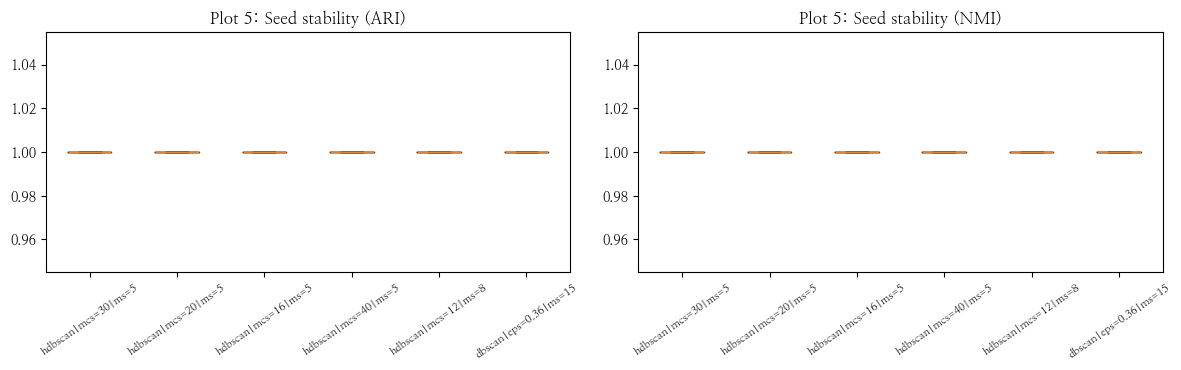

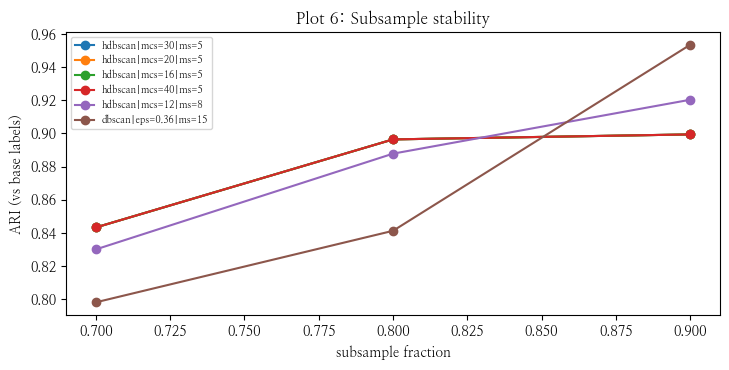

In [7]:
top_runs = valid_df.sort_values('score', ascending=False).head(6).copy()
display(top_runs[['run_id', 'backbone', 'method', 'n_clusters', 'noise_ratio', 'score']])

st_rows: List[Dict[str, Any]] = []
sub_rows: List[Dict[str, Any]] = []

for _, rr in top_runs.iterrows():
    rid = rr['run_id']
    bb = rr['backbone']
    method = rr['method']
    params = rr['params']
    X = backbone_data[bb]['X']
    base = labels_store[rid]

    for sd in SEEDS_STABILITY:
        if method == 'kmeans':
            model = KMeans(n_clusters=int(params['k']), random_state=int(sd), n_init='auto')
            lb = model.fit_predict(X).astype(np.int64)
        elif method == 'dbscan':
            model = DBSCAN(eps=float(params['eps']), min_samples=int(params['min_samples']), metric=params.get('metric', 'cosine'))
            lb = model.fit_predict(X).astype(np.int64)
        else:
            if not HAS_HDBSCAN:
                continue
            model = hdbscan.HDBSCAN(
                min_cluster_size=int(params['min_cluster_size']),
                min_samples=(None if params['min_samples'] is None else int(params['min_samples'])),
                metric=params.get('metric', 'euclidean'),
            )
            lb = model.fit_predict(X).astype(np.int64)
        st_rows.append({'run_id': rid, 'seed': int(sd), 'ARI': float(adjusted_rand_score(base, lb)), 'NMI': float(normalized_mutual_info_score(base, lb))})

    for frac in SUBSAMPLE_FRACS:
        rs = np.random.RandomState(RANDOM_STATE + int(frac * 1000))
        idx = rs.choice(np.arange(X.shape[0]), size=max(10, int(X.shape[0] * frac)), replace=False)
        Xs = X[idx]
        bs = base[idx]

        if method == 'kmeans':
            model = KMeans(n_clusters=int(params['k']), random_state=RANDOM_STATE, n_init='auto')
            lb = model.fit_predict(Xs).astype(np.int64)
        elif method == 'dbscan':
            model = DBSCAN(eps=float(params['eps']), min_samples=int(params['min_samples']), metric=params.get('metric', 'cosine'))
            lb = model.fit_predict(Xs).astype(np.int64)
        else:
            if not HAS_HDBSCAN:
                continue
            model = hdbscan.HDBSCAN(
                min_cluster_size=int(params['min_cluster_size']),
                min_samples=(None if params['min_samples'] is None else int(params['min_samples'])),
                metric=params.get('metric', 'euclidean'),
            )
            lb = model.fit_predict(Xs).astype(np.int64)

        sub_rows.append({'run_id': rid, 'frac': float(frac), 'ARI': float(adjusted_rand_score(bs, lb))})

st_df = pd.DataFrame(st_rows)
sub_df = pd.DataFrame(sub_rows)

# Plot 5
if not st_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    run_order = top_runs['run_id'].tolist()
    data_ari = [st_df.loc[st_df['run_id'] == rid, 'ARI'].values for rid in run_order]
    data_nmi = [st_df.loc[st_df['run_id'] == rid, 'NMI'].values for rid in run_order]
    axes[0].boxplot(data_ari, labels=[r.split('|', 1)[1] for r in run_order], showfliers=False)
    axes[0].set_title('Plot 5: Seed stability (ARI)')
    axes[0].tick_params(axis='x', labelrotation=35, labelsize=8)
    axes[1].boxplot(data_nmi, labels=[r.split('|', 1)[1] for r in run_order], showfliers=False)
    axes[1].set_title('Plot 5: Seed stability (NMI)')
    axes[1].tick_params(axis='x', labelrotation=35, labelsize=8)
    fig.tight_layout()
    plt.show()

# Plot 6
if not sub_df.empty:
    fig, ax = plt.subplots(figsize=(7.4, 3.8))
    for rid in top_runs['run_id']:
        g = sub_df[sub_df['run_id'] == rid].sort_values('frac')
        if g.empty:
            continue
        ax.plot(g['frac'].values, g['ARI'].values, marker='o', label=rid.split('|', 1)[1])
    ax.set_xlabel('subsample fraction')
    ax.set_ylabel('ARI (vs base labels)')
    ax.set_title('Plot 6: Subsample stability')
    ax.legend(fontsize=7, loc='best')
    fig.tight_layout()
    plt.show()

## 6) UMAP vs t-SNE 시각화 비교

### Plot 3
- Top run UMAP small multiples

### Plot 4
- 최종 후보 UMAP vs t-SNE pair

/home/urp_jwl2/miniconda3/envs/ytvenv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


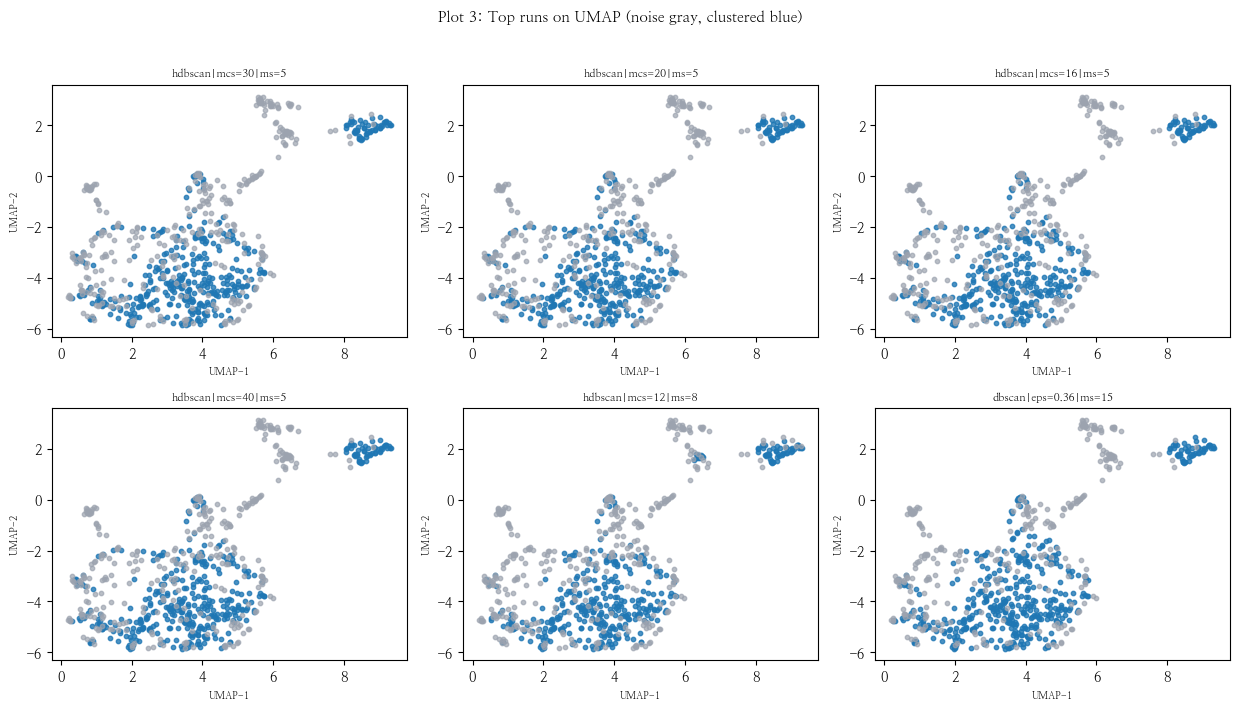

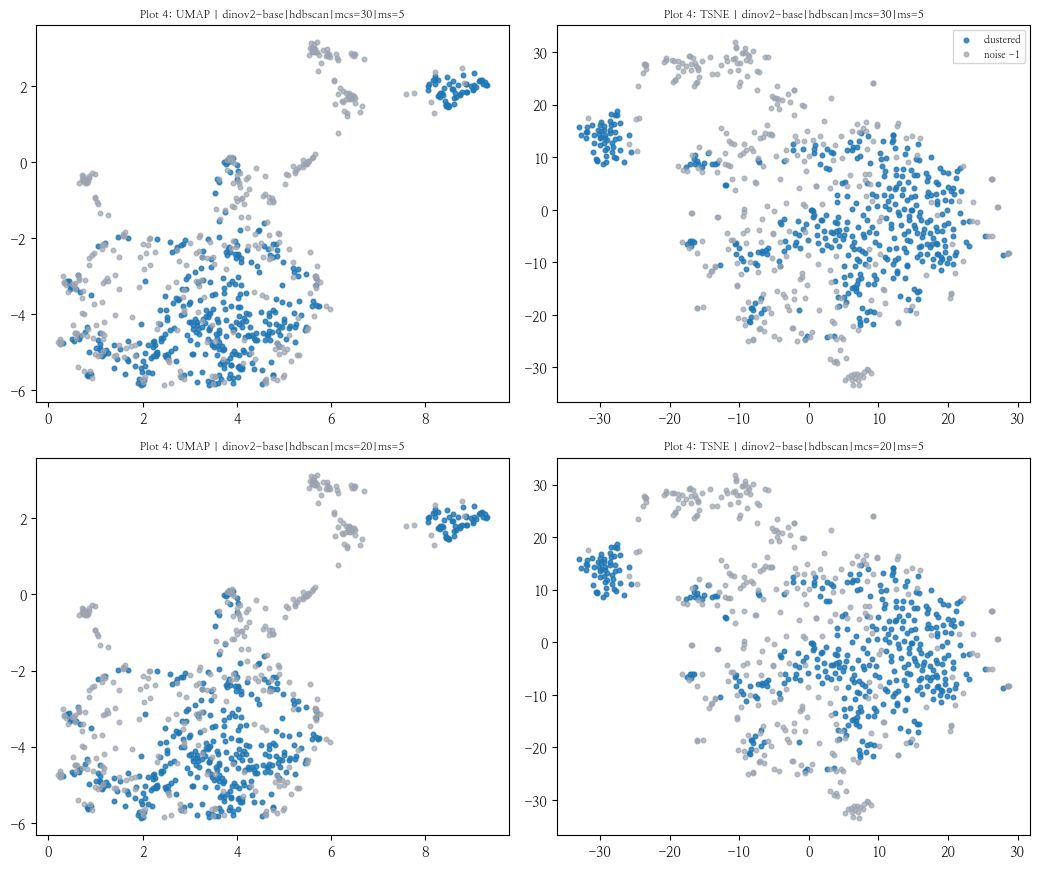

In [8]:
xy_map: Dict[str, Dict[str, np.ndarray]] = {}
for bb, d in backbone_data.items():
    X = d['X']
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(UMAP_NEIGHBORS, max(2, X.shape[0] - 1)),
        min_dist=UMAP_MIN_DIST,
        metric='cosine',
        random_state=RANDOM_STATE,
    )
    xy_umap = reducer.fit_transform(X)
    xy_tsne = TSNE(n_components=2, perplexity=min(TSNE_PERPLEXITY, max(5, (X.shape[0] - 1) // 3)), random_state=RANDOM_STATE, init='pca').fit_transform(X)
    xy_map[bb] = {'umap': xy_umap, 'tsne': xy_tsne}

# Plot 3: Top run small multiples on UMAP
plot_runs = top_runs.head(6)['run_id'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.2), squeeze=False)
for i, rid in enumerate(plot_runs):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    bb = rid.split('|')[0]
    xy = xy_map[bb]['umap']
    lb = labels_store[rid]
    m_noise = lb == -1
    m_clustered = ~m_noise
    if np.any(m_clustered):
        ax.scatter(xy[m_clustered, 0], xy[m_clustered, 1], s=10, alpha=0.8, color='#1f77b4')
    if np.any(m_noise):
        ax.scatter(xy[m_noise, 0], xy[m_noise, 1], s=10, alpha=0.7, color='#9ca3af')
    ax.set_title(rid.split('|', 1)[1], fontsize=8)
    ax.set_xlabel('UMAP-1', fontsize=7)
    ax.set_ylabel('UMAP-2', fontsize=7)
for j in range(len(plot_runs), 6):
    r, c = divmod(j, 3)
    axes[r, c].axis('off')
fig.suptitle('Plot 3: Top runs on UMAP (noise gray, clustered blue)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# Plot 4: Best 2 runs UMAP vs t-SNE
final_candidates = valid_df.sort_values('score', ascending=False).head(2).copy()
if not final_candidates.empty:
    fig, axes = plt.subplots(len(final_candidates), 2, figsize=(10.5, 4.4 * len(final_candidates)), squeeze=False)
    for i, (_, rr) in enumerate(final_candidates.iterrows()):
        rid = rr['run_id']
        bb = rr['backbone']
        lb = labels_store[rid]
        for j, proj in enumerate(['umap', 'tsne']):
            ax = axes[i, j]
            xy = xy_map[bb][proj]
            m_noise = lb == -1
            m_clustered = ~m_noise
            if np.any(m_clustered):
                ax.scatter(xy[m_clustered, 0], xy[m_clustered, 1], s=11, alpha=0.82, color='#1f77b4', label='clustered')
            if np.any(m_noise):
                ax.scatter(xy[m_noise, 0], xy[m_noise, 1], s=11, alpha=0.7, color='#9ca3af', label='noise -1')
            ax.set_title(f'Plot 4: {proj.upper()} | {rid}', fontsize=8)
            if i == 0 and j == 1:
                ax.legend(fontsize=7, loc='best')
    fig.tight_layout()
    plt.show()

## 7) 피처 해석 (오버레이 + 분포)

### Plot 7
- 연속형 피처 오버레이 그리드

### Plot 8
- Top-1 age argmax 범주색

### Plot 9
- 클러스터별 피처 분포 박스플롯

final candidate: dinov2-base|hdbscan|mcs=30|ms=5
n_clusters: 2 noise_ratio: 0.4600262123197903


,feature,rho,p,n
16,green_ratio_ratio,-0.123388,0.000641,762
20,pink_ratio_ratio,-0.123019,0.000666,762
12,saturated_ratio,0.116898,0.001226,762
19,purple_ratio_ratio,-0.116440,0.001282,762
6,age_65~,-0.103759,0.004216,759
21,person_ratio,0.085746,0.017912,762
13,red_ratio_ratio,-0.081597,0.024291,762
5,age_55~64,-0.076678,0.034201,763
1,age_18~24,0.067091,0.063989,763
2,age_25~34,0.064091,0.076851,763


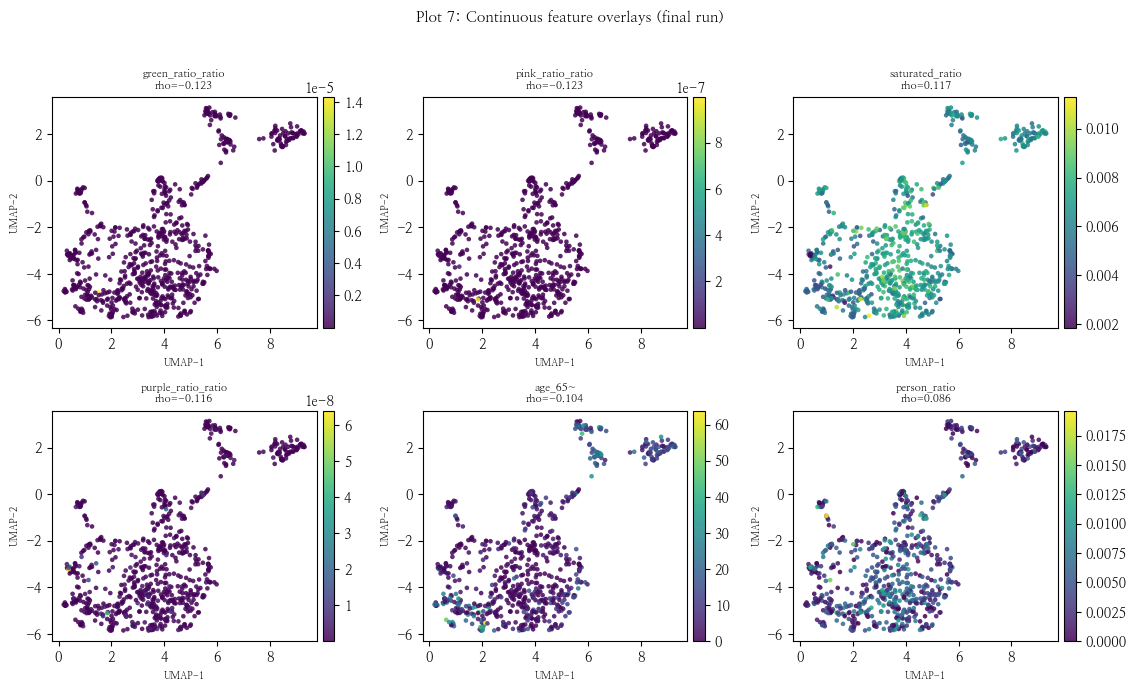

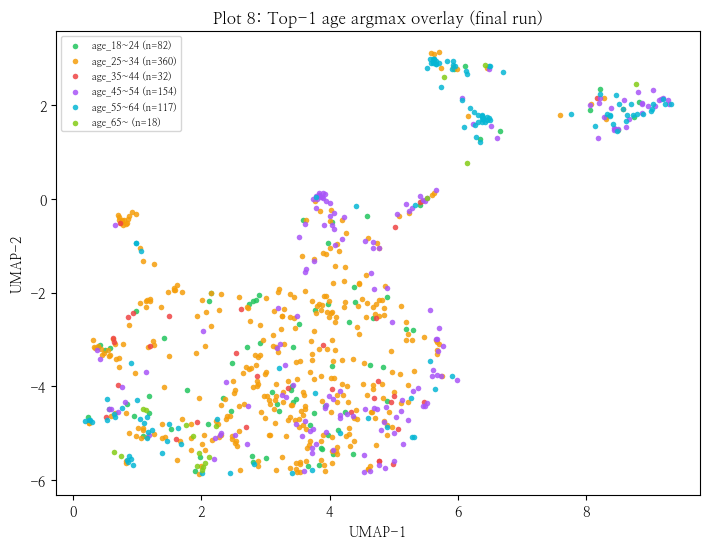

/tmp/ipykernel_125356/3771362520.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in cls], showfliers=False)
/tmp/ipykernel_125356/3771362520.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in cls], showfliers=False)
/tmp/ipykernel_125356/3771362520.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in cls], showfliers=False)
/tmp/ipykernel_125356/3771362520.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for t

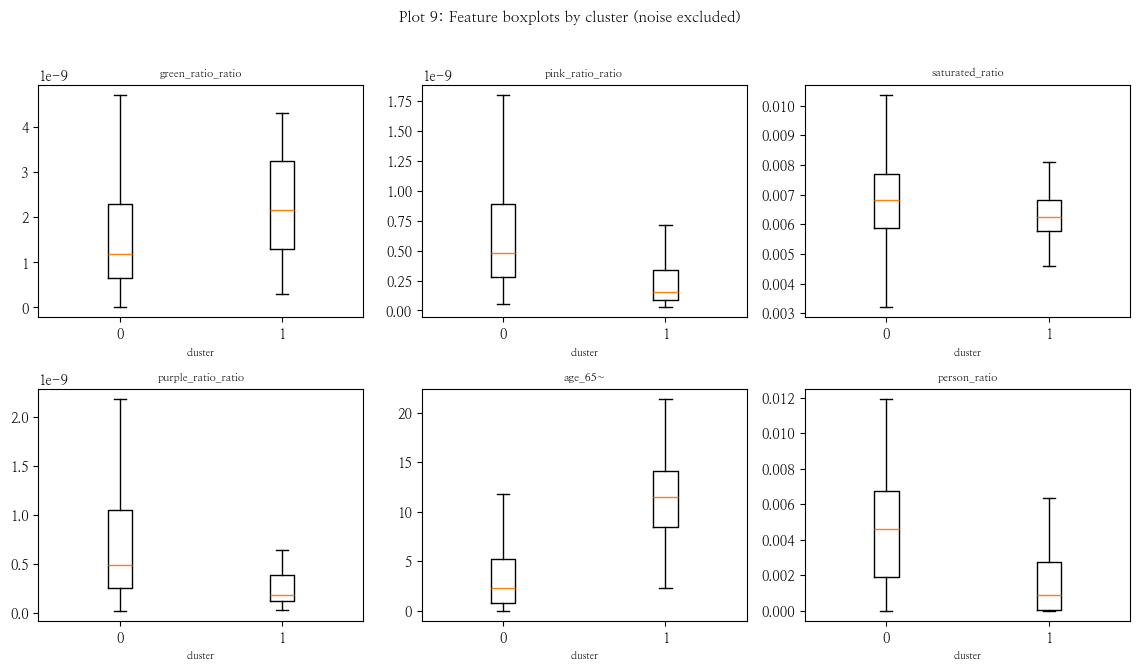

In [9]:
# 최종 후보(임시): valid_df 1위
final_run = valid_df.sort_values('score', ascending=False).iloc[0]
final_run_id = str(final_run['run_id'])
final_backbone = str(final_run['backbone'])
final_labels = labels_store[final_run_id]
final_xy = xy_map[final_backbone]['umap']
final_merged = backbone_data[final_backbone]['merged']
final_F = backbone_data[final_backbone]['F']
final_feature_cols = backbone_data[final_backbone]['feature_cols']

print('final candidate:', final_run_id)
print('n_clusters:', int(len(set(final_labels.tolist()) - {-1})), 'noise_ratio:', float((final_labels == -1).sum()/len(final_labels)))

# Plot 7: feature overlays (top 6 by |spearman|)
from scipy.stats import spearmanr

summ = []
for j, col in enumerate(final_feature_cols):
    v = final_F[:, j]
    m = np.isfinite(v)
    if m.sum() < 5:
        continue
    rho, p = spearmanr(final_labels[m], v[m])
    summ.append({'feature': col, 'rho': float(rho), 'p': float(p), 'n': int(m.sum())})

summ_df = pd.DataFrame(summ).sort_values('rho', key=np.abs, ascending=False)
display(summ_df.head(10))

plot_feats = summ_df.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.0), squeeze=False)
for i, feat in enumerate(plot_feats):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    j = final_feature_cols.index(feat)
    v = final_F[:, j]
    m = np.isfinite(v)
    sc = ax.scatter(final_xy[m, 0], final_xy[m, 1], c=v[m], cmap='viridis', s=11, alpha=0.85, linewidths=0)
    rho = float(summ_df.loc[summ_df['feature'] == feat, 'rho'].iloc[0])
    ax.set_title(f'{feat}\nrho={rho:.3f}', fontsize=8)
    ax.set_xlabel('UMAP-1', fontsize=7)
    ax.set_ylabel('UMAP-2', fontsize=7)
    fig.colorbar(sc, ax=ax, fraction=0.08, pad=0.02)
fig.suptitle('Plot 7: Continuous feature overlays (final run)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# Plot 8: top-1 age argmax
age_cols = [c for c in final_feature_cols if c.startswith('age_')]
if age_cols:
    A = final_merged[age_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float64)
    valid = np.isfinite(A).any(axis=1)
    fill = np.where(np.isfinite(A), A, -np.inf)
    top_idx = np.full(A.shape[0], -1, dtype=int)
    top_idx[valid] = np.argmax(fill[valid], axis=1)

    colors = ['#3b82f6','#22c55e','#f59e0b','#ef4444','#a855f7','#06b6d4','#84cc16'][:len(age_cols)]
    fig, ax = plt.subplots(figsize=(7.2, 5.6))
    for i, col in enumerate(age_cols):
        mm = valid & (top_idx == i)
        if not np.any(mm):
            continue
        ax.scatter(final_xy[mm, 0], final_xy[mm, 1], s=16, alpha=0.85, linewidths=0, color=colors[i], label=f'{col} (n={int(mm.sum())})')
    ax.set_title('Plot 8: Top-1 age argmax overlay (final run)')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=7, loc='best')
    fig.tight_layout()
    plt.show()

# Plot 9: feature distributions by cluster (top 6)
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.8), squeeze=False)
for i, feat in enumerate(plot_feats):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    y = pd.to_numeric(final_merged[feat], errors='coerce')
    dfp = pd.DataFrame({'cluster': final_labels, 'value': y})
    dfp = dfp[np.isfinite(dfp['value']) & (dfp['cluster'] != -1)]
    cls = sorted(dfp['cluster'].unique())
    data = [dfp.loc[dfp['cluster'] == k, 'value'].values for k in cls]
    if len(data) >= 2:
        ax.boxplot(data, labels=[str(k) for k in cls], showfliers=False)
    ax.set_title(feat, fontsize=8)
    ax.set_xlabel('cluster', fontsize=7)
fig.suptitle('Plot 9: Feature boxplots by cluster (noise excluded)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 8) Permutation importance-style + 최종 선정 근거

### Plot 10
- 피처 셔플 시 label 예측 성능(균형정확도) 감소량

### Plot 11
- 최종 선택 요약 카드(점수/안정성/해석성)

,feature,delta_bal_acc
4,age_45~54,0.076923
6,age_65~,0.076923
9,laba_mean,0.076923
13,red_ratio_ratio,0.076923
19,purple_ratio_ratio,0.076923
14,orange_ratio_ratio,0.044017
20,pink_ratio_ratio,0.044017
1,age_18~24,0.038462
16,green_ratio_ratio,0.038462
2,age_25~34,0.038462


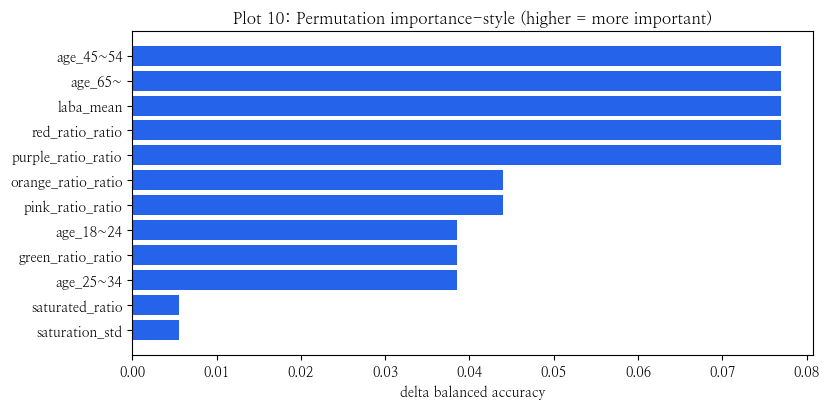

{
  "selected_run_id": "dinov2-base|hdbscan|mcs=30|ms=5",
  "backbone": "dinov2-base",
  "method": "hdbscan",
  "n_clusters": 2,
  "noise_ratio": 0.4600262123197903,
  "quality_score": 0.13086884424757558,
  "silhouette_pref": 0.2270559543506997,
  "top_interpret_features": [
    "age_45~54",
    "age_65~",
    "laba_mean",
    "red_ratio_ratio",
    "purple_ratio_ratio"
  ]
}


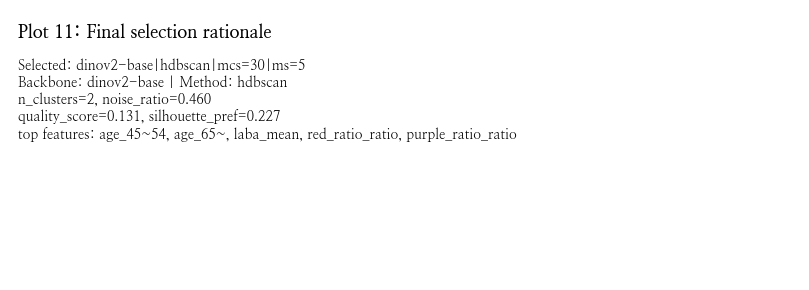

In [10]:
# Plot 10: permutation importance-style (feature -> cluster label predictability)
mask = final_labels != -1
Xf = pd.DataFrame(final_F[mask], columns=final_feature_cols).apply(pd.to_numeric, errors='coerce')
Xf = Xf.fillna(Xf.median(numeric_only=True))
yf = final_labels[mask]

if len(np.unique(yf)) >= 2 and Xf.shape[0] >= 80:
    Xtr, Xte, ytr, yte = train_test_split(Xf, yf, test_size=0.25, random_state=RANDOM_STATE, stratify=yf)
    clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
    clf.fit(Xtr, ytr)
    base = balanced_accuracy_score(yte, clf.predict(Xte))

    drops = []
    rng = np.random.RandomState(RANDOM_STATE)
    for col in Xte.columns:
        Xt = Xte.copy()
        Xt[col] = rng.permutation(Xt[col].values)
        sc = balanced_accuracy_score(yte, clf.predict(Xt))
        drops.append({'feature': col, 'delta_bal_acc': float(base - sc)})

    perm_df = pd.DataFrame(drops).sort_values('delta_bal_acc', ascending=False)
    display(perm_df.head(12))

    fig, ax = plt.subplots(figsize=(8.4, 4.2))
    top = perm_df.head(12)
    ax.barh(top['feature'][::-1], top['delta_bal_acc'][::-1], color='#2563eb')
    ax.set_title('Plot 10: Permutation importance-style (higher = more important)')
    ax.set_xlabel('delta balanced accuracy')
    fig.tight_layout()
    plt.show()
else:
    perm_df = pd.DataFrame(columns=['feature', 'delta_bal_acc'])
    print('Permutation importance skipped: not enough clustered samples/classes.')

# Plot 11: final selection summary card
final_summary = {
    'selected_run_id': final_run_id,
    'backbone': final_backbone,
    'method': final_run['method'],
    'n_clusters': int(len(set(final_labels.tolist()) - {-1})),
    'noise_ratio': float((final_labels == -1).sum() / len(final_labels)),
    'quality_score': float(final_run['score']),
    'silhouette_pref': float(final_run['sil_pref']) if np.isfinite(final_run['sil_pref']) else np.nan,
    'top_interpret_features': perm_df.head(5)['feature'].tolist() if not perm_df.empty else [],
}
print(json.dumps(final_summary, ensure_ascii=False, indent=2))

fig, ax = plt.subplots(figsize=(8.2, 3.0))
ax.axis('off')
lines = [
    f"Selected: {final_summary['selected_run_id']}",
    f"Backbone: {final_summary['backbone']} | Method: {final_summary['method']}",
    f"n_clusters={final_summary['n_clusters']}, noise_ratio={final_summary['noise_ratio']:.3f}",
    f"quality_score={final_summary['quality_score']:.3f}, silhouette_pref={final_summary['silhouette_pref']:.3f}",
    f"top features: {', '.join(final_summary['top_interpret_features'][:5])}",
]
ax.text(0.01, 0.95, 'Plot 11: Final selection rationale', fontsize=13, va='top', fontweight='bold')
ax.text(0.01, 0.82, '\n'.join(lines), fontsize=10, va='top')
fig.tight_layout()
plt.show()